# 3.2 — Абляции, метрики по группам и out-of-distribution тесты

**Папка 3, подноутбук 2.** Анализ устойчивости и вклада компонентов: метрики по типам
грунта и режимам нагружения, абляции DPI-Flow и EVT-NeuralSSM, OOD-тесты (экстраполяция
«короткий → длинный горизонт» и удержанный регион слабых грунтов). Все рисунки и таблицы
— на английском.

## Окружение, данные и модели

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "demo_run"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset
from liquefaction_ai.training import load_model_metadata, load_weights_into
from liquefaction_ai.models import (DPIFlow, EVTNeuralSSM, GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline, TransformerBaseline, FTTransformer,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow,
                                    NeuralODENoPhysics, FlowNoODE, DPIEvtNet)
from liquefaction_ai.evaluation import collect_outputs, compute_metrics, english_metric_table

CLASS_REGISTRY = {"RiskMLP": RiskMLP, "GRUBaseline": GRUBaseline, "TCNBaseline": TCNBaseline, "LSTMBaseline": LSTMBaseline, "TransformerBaseline": TransformerBaseline, "FTTransformer": FTTransformer, "PINNBaseline": PINNBaseline, "DeepStateBaseline": DeepStateBaseline, "RealNVPFlow": RealNVPFlow, "NeuralSplineFlow": NeuralSplineFlow,
                  "DPIFlow": DPIFlow, "EVTNeuralSSM": EVTNeuralSSM, "DPIEvtNet": DPIEvtNet}
MODEL_NAMES = ["mlp_risk", "gru", "tcn", "lstm", "transformer", "ft_transformer", "pinn", "deepstate", "realnvp", "nsf", "dpi_flow", "evt_ssm", "dpi_evt"]

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
test = benchmark["test"]


def load_trained(name):
    """Восстановить модель по сохранённым гиперпараметрам и весам."""
    hp, hist = load_model_metadata(MODELS_DIR, name)
    model = CLASS_REGISTRY[hp["model_type"]](**hp["model_kwargs"])
    load_weights_into(model, MODELS_DIR, name, device)
    return model, hp, hist
from liquefaction_ai.evaluation import (filter_split, grouped_metrics, is_holdout_region,
                                        run_quick_experiment, subsample_split)
from liquefaction_ai.constants import LOAD_DISPLAY_NAMES_EN, SOIL_DISPLAY_NAMES_EN
from liquefaction_ai.viz import bar, grouped_bar

## Metrics by soil type and loading regime (DPI-Flow)

,soil_en,N samples,Liquefaction rate,Mean predicted risk,n_nliq_observed,Mean |ΔN_liq| (cycles),Mean log-error N_liq,Mean trajectory RMSE,Mean interval width,Physics violations,AUROC
3,Loam,47,0.6170,0.6161,47.0,19.189899,0.1148,0.1170,0.4671,0.0,1.00
0,Clay,42,0.4286,0.4283,42.0,13.827000,0.1037,0.1348,0.4153,0.0,1.00
4,Medium sand,27,0.7407,0.6853,27.0,48.941799,0.2348,0.2102,0.7436,0.0,1.00
1,Fine sand,26,0.0385,0.0927,26.0,20.684099,0.0105,0.0964,0.3151,0.0,0.52
5,Silty sand,24,0.7500,0.7467,24.0,23.469299,0.1787,0.1124,0.4815,0.0,1.00
2,Gravelly sand,2,0.0000,0.0949,2.0,0.000000,0.0000,0.0912,0.3141,0.0,NaN


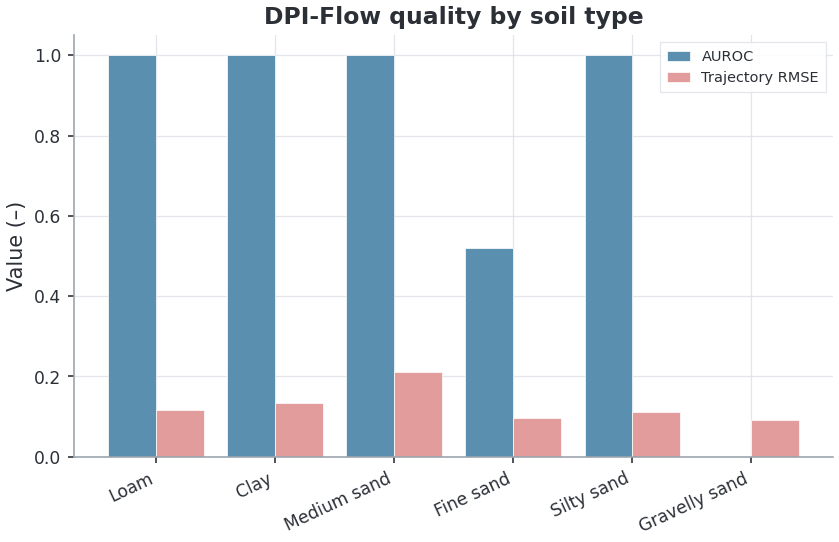

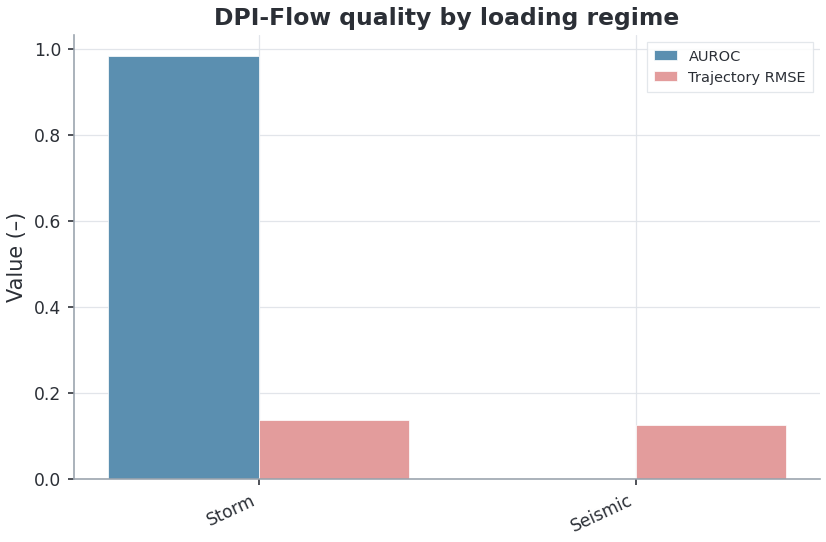

In [2]:
dpi, hp, _ = load_trained("dpi_flow")
out = collect_outputs(dpi, test, config, device)
_, sample_df = compute_metrics("DPI-Flow", out, test, config)
sample_df["soil_en"] = sample_df["soil_type"].map(SOIL_DISPLAY_NAMES_EN)
sample_df["load_en"] = sample_df["load_mode"].map(LOAD_DISPLAY_NAMES_EN)
soil_metrics = grouped_metrics(sample_df, "soil_en")
load_metrics = grouped_metrics(sample_df, "load_en")
display(english_metric_table(soil_metrics).round(4))
grouped_bar(soil_metrics["soil_en"].tolist(),
            {"AUROC": soil_metrics["AUROC"].tolist(), "Trajectory RMSE": soil_metrics["mean_traj_rmse"].tolist()},
            title="DPI-Flow quality by soil type", ylabel="Value (–)",
            save=SAVE_FIGS, fig_id="3_2_metrics_by_soil").show()
grouped_bar(load_metrics["load_en"].tolist(),
            {"AUROC": load_metrics["AUROC"].tolist(), "Trajectory RMSE": load_metrics["mean_traj_rmse"].tolist()},
            title="DPI-Flow quality by loading regime", ylabel="Value (–)",
            save=SAVE_FIGS, fig_id="3_2_metrics_by_load").show()

## Component ablations

[DPI-Flow (full)] эпоха 01 | обучение=3.5759 | валидация=0.0692 | stale=0/12
[DPI-Flow (full)] эпоха 02 | обучение=-0.6345 | валидация=-0.5598 | stale=0/12
[DPI-Flow w/o calibration] эпоха 01 | обучение=1.6639 | валидация=-0.5206 | stale=0/12
[DPI-Flow w/o calibration] эпоха 02 | обучение=-0.8689 | валидация=-0.5933 | stale=0/12
[DPI-Flow w/o probabilistic head] эпоха 01 | обучение=2.5814 | валидация=-0.8393 | stale=0/12
[DPI-Flow w/o probabilistic head] эпоха 02 | обучение=-0.7091 | валидация=-0.8412 | stale=0/12
[DPI-Flow w/o ODE layer] эпоха 01 | обучение=0.3343 | валидация=-0.0456 | stale=0/12
[DPI-Flow w/o ODE layer] эпоха 02 | обучение=-0.6499 | валидация=-0.3588 | stale=0/12
[ODE w/o flow] эпоха 01 | обучение=3.9003 | валидация=-0.1901 | stale=0/12
[ODE w/o flow] эпоха 02 | обучение=-0.2864 | валидация=-0.5820 | stale=0/12
[Flow w/o ODE] эпоха 01 | обучение=0.2614 | валидация=-0.1457 | stale=0/12
[Flow w/o ODE] эпоха 02 | обучение=-0.4487 | валидация=-0.7483 | stale=0/12
[Neural

,Model,Trajectory RMSE,AUROC,Brier
1,DPI-Flow w/o calibration,0.1491,0.9965,0.0329
0,DPI-Flow (full),0.1502,0.9990,0.0290
3,DPI-Flow w/o ODE layer,0.1644,0.9979,0.0140
4,ODE w/o flow,0.1654,0.9940,0.0396
2,DPI-Flow w/o probabilistic head,0.1671,0.9966,0.0523
6,Neural ODE w/o physics,0.2616,0.8520,0.2354
5,Flow w/o ODE,0.3062,0.9987,0.0579
8,EVT w/o trigger,0.4603,0.9967,0.0329
9,EVT w/o post-event dynamics,0.4639,0.9636,0.1640
7,EVT (full),0.4650,0.9991,0.0430


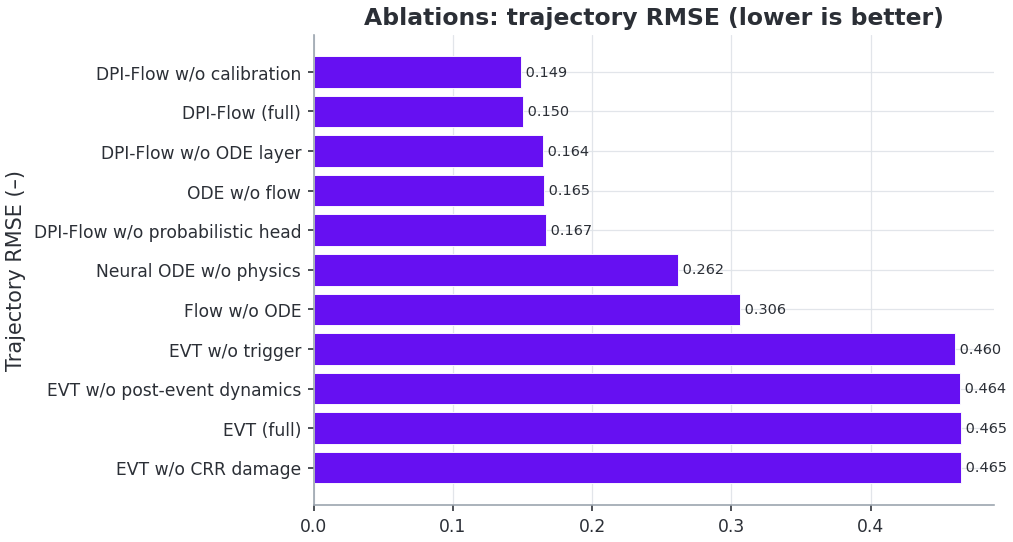

In [3]:
sub = min(config.ablation_subset, 2400)
atrain = subsample_split(benchmark["train"], int(sub * 0.7), config.seed)
aval = subsample_split(benchmark["val"], int(sub * 0.15), config.seed + 1)
atest = subsample_split(benchmark["test"], int(sub * 0.15), config.seed + 2)
sd, pdim, qd = static_dim, prefix_dim, seq_dim = (benchmark["train"]["static"].shape[1],
    benchmark["train"]["prefix_summary"].shape[1], benchmark["train"]["seq_in"].shape[-1])
mcr, sl, pl = config.max_cycle_reference, config.seq_len, config.prefix_len
ablation_specs = [
    ("DPI-Flow (full)", DPIFlow(sd, pdim, sl, pl, mcr, calibration_steps=2, use_analytical_layer=True)),
    ("DPI-Flow w/o calibration", DPIFlow(sd, pdim, sl, pl, mcr, calibration_steps=0, use_analytical_layer=True)),
    ("DPI-Flow w/o probabilistic head", DPIFlow(sd, pdim, sl, pl, mcr, probabilistic=False, calibration_steps=2)),
    ("DPI-Flow w/o ODE layer", DPIFlow(sd, pdim, sl, pl, mcr, calibration_steps=0, use_analytical_layer=False)),
    # --- покомпонентные абляции (изоляция вклада ODE / flow / физики) ---
    ("ODE w/o flow", DPIFlow(sd, pdim, sl, pl, mcr, calibration_steps=2, use_analytical_layer=True, use_flow=False)),
    ("Flow w/o ODE", FlowNoODE(sd, pdim, sl)),
    ("Neural ODE w/o physics", NeuralODENoPhysics(sd, qd)),
    ("EVT (full)", EVTNeuralSSM(sd, pdim, qd, sl, pl, mcr)),
    ("EVT w/o trigger", EVTNeuralSSM(sd, pdim, qd, sl, pl, mcr, use_trigger_head=False)),
    ("EVT w/o post-event dynamics", EVTNeuralSSM(sd, pdim, qd, sl, pl, mcr, structured_post_event=False)),
    ("EVT w/o CRR damage", EVTNeuralSSM(sd, pdim, qd, sl, pl, mcr, use_crr_damage=False)),
]
ablation_rows = [run_quick_experiment(n, m, atrain, aval, atest, epochs=config.ablation_epochs,
                                      config=config, device=device) for n, m in ablation_specs]
ablation_df = pd.DataFrame(ablation_rows).sort_values("Traj_RMSE")
display(english_metric_table(ablation_df)[["Model", "Trajectory RMSE", "AUROC", "Brier"]].round(4))
bar(ablation_df["model"], ablation_df["Traj_RMSE"], title="Ablations: trajectory RMSE (lower is better)",
    ylabel="Trajectory RMSE (–)", color="#6610f2", horizontal=True,
    save=SAVE_FIGS, fig_id="3_2_ablations_rmse").show()

## Out-of-distribution tests

[TCN] эпоха 01 | обучение=0.3236 | валидация=0.2488 | stale=0/12
[TCN] эпоха 02 | обучение=0.2254 | валидация=0.0026 | stale=0/12
[TCN] эпоха 01 | обучение=0.3339 | валидация=0.1816 | stale=0/12
[TCN] эпоха 02 | обучение=0.2052 | валидация=1.3013 | stale=1/12
[DPI-Flow] эпоха 01 | обучение=4.7309 | валидация=0.1592 | stale=0/12
[DPI-Flow] эпоха 02 | обучение=-0.6227 | валидация=-0.3107 | stale=0/12
[DPI-Flow] эпоха 01 | обучение=2.8010 | валидация=-0.7746 | stale=0/12
[DPI-Flow] эпоха 02 | обучение=-0.7438 | валидация=-1.0908 | stale=0/12
[EVT-NeuralSSM] эпоха 01 | обучение=5.9933 | валидация=-0.0419 | stale=0/12
[EVT-NeuralSSM] эпоха 02 | обучение=-0.5472 | валидация=-0.3747 | stale=0/12
[EVT-NeuralSSM] эпоха 01 | обучение=3.0280 | валидация=-0.1219 | stale=0/12
[EVT-NeuralSSM] эпоха 02 | обучение=0.4606 | валидация=-0.5878 | stale=0/12


,Model,test,Trajectory RMSE,AUROC
0,TCN,short→long,0.2464,0.9756
1,TCN,held-out region,0.3839,NaN
2,DPI-Flow,short→long,0.6261,0.9593
3,DPI-Flow,held-out region,0.5778,NaN
4,EVT-NeuralSSM,short→long,0.5989,0.9472
5,EVT-NeuralSSM,held-out region,0.5414,NaN


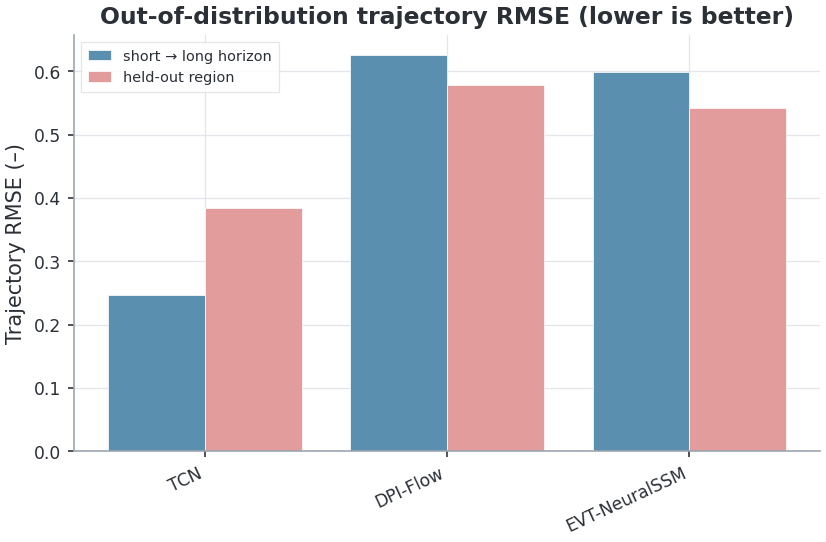

In [4]:
train_meta = benchmark["train"]["meta"]; val_meta = benchmark["val"]["meta"]; test_meta = benchmark["test"]["meta"]
short_thr = float(train_meta["N_max"].quantile(0.60)); long_thr = float(test_meta["N_max"].quantile(0.80))
short_train = filter_split(benchmark["train"], train_meta["N_max"].to_numpy() <= short_thr)
short_val = filter_split(benchmark["val"], val_meta["N_max"].to_numpy() <= short_thr)
long_test = filter_split(benchmark["test"], test_meta["N_max"].to_numpy() >= long_thr)
e_thr = float(benchmark["meta"]["e"].quantile(0.75)); vs_thr = float(benchmark["meta"]["V_s"].quantile(0.25))
region_test = filter_split(benchmark["test"], is_holdout_region(test_meta, e_thr, vs_thr))
hold_train = filter_split(benchmark["train"], ~is_holdout_region(train_meta, e_thr, vs_thr))
hold_val = filter_split(benchmark["val"], ~is_holdout_region(val_meta, e_thr, vs_thr))
short_train = subsample_split(short_train, 1100, config.seed); short_val = subsample_split(short_val, 300, config.seed + 1)
long_test = subsample_split(long_test, 700, config.seed + 2)
hold_train = subsample_split(hold_train, 1100, config.seed + 3); hold_val = subsample_split(hold_val, 300, config.seed + 4)
region_test = subsample_split(region_test, 700, config.seed + 5)

def fresh(kind):
    if kind == "tcn": return TCNBaseline(sd, qd, 96)
    if kind == "dpi": return DPIFlow(sd, pdim, sl, pl, mcr, calibration_steps=2)
    return EVTNeuralSSM(sd, pdim, qd, sl, pl, mcr)

ood_rows = []
for disp, kind in [("TCN", "tcn"), ("DPI-Flow", "dpi"), ("EVT-NeuralSSM", "evt")]:
    ood_rows.append({**run_quick_experiment(disp, fresh(kind), short_train, short_val, long_test,
                     epochs=config.ablation_epochs, config=config, device=device), "test": "short→long"})
    ood_rows.append({**run_quick_experiment(disp, fresh(kind), hold_train, hold_val, region_test,
                     epochs=config.ablation_epochs, config=config, device=device), "test": "held-out region"})
ood_df = pd.DataFrame(ood_rows)
display(english_metric_table(ood_df)[["Model", "test", "Trajectory RMSE", "AUROC"]].round(4))
sl_df = ood_df[ood_df["test"] == "short→long"]; rg_df = ood_df[ood_df["test"] == "held-out region"]
grouped_bar(sl_df["model"].tolist(),
            {"short → long horizon": sl_df["Traj_RMSE"].tolist(), "held-out region": rg_df["Traj_RMSE"].tolist()},
            title="Out-of-distribution trajectory RMSE (lower is better)", ylabel="Trajectory RMSE (–)",
            save=SAVE_FIGS, fig_id="3_2_ood_rmse").show()

## Итог

Абляции подтверждают вклад компонентов; структурированные модели устойчивее в OOD.
Дальше — **3.3 разбор кейсов**.


=== OOD по: площадка (site) ===


,object,N samples,Mean trajectory RMSE,Mean log-error N_liq,Physics violations,AUROC
0,Облако разжижения · Потенциал разжижения/333-2...,71,0.1254,0.2324,0.0,NaN
2,Облако разжижения · Штормовое разжижение/390-2...,66,0.1612,0.0394,0.0,1.0000
1,Облако разжижения · Штормовое разжижение/255-2...,31,0.0863,0.0501,0.0,0.7619


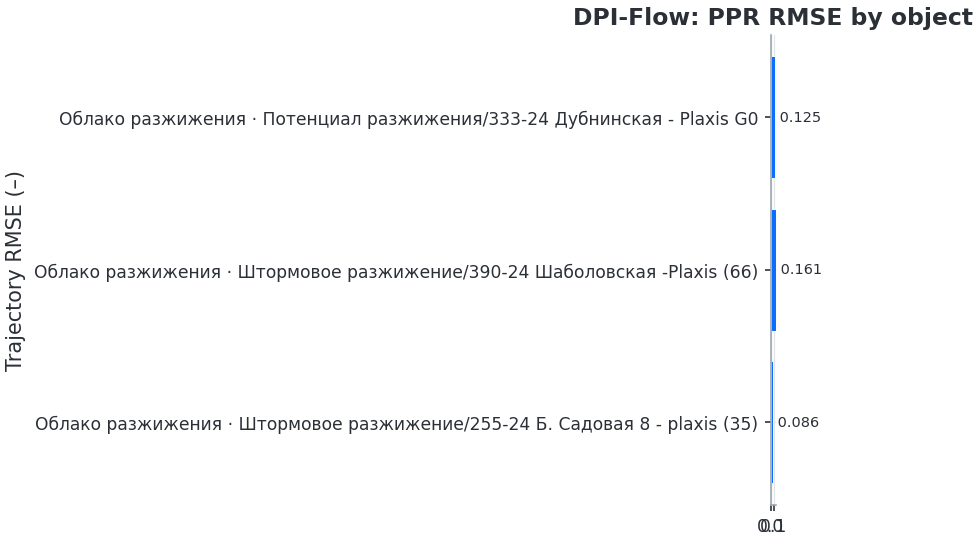


=== OOD по: тип грунта ===


,soil_en,N samples,Mean trajectory RMSE,Mean log-error N_liq,Physics violations,AUROC
3,Loam,47,0.1170,0.1148,0.0,1.00
0,Clay,42,0.1348,0.1037,0.0,1.00
4,Medium sand,27,0.2102,0.2348,0.0,1.00
1,Fine sand,26,0.0964,0.0105,0.0,0.52
5,Silty sand,24,0.1124,0.1787,0.0,1.00
2,Gravelly sand,2,0.0912,0.0000,0.0,NaN


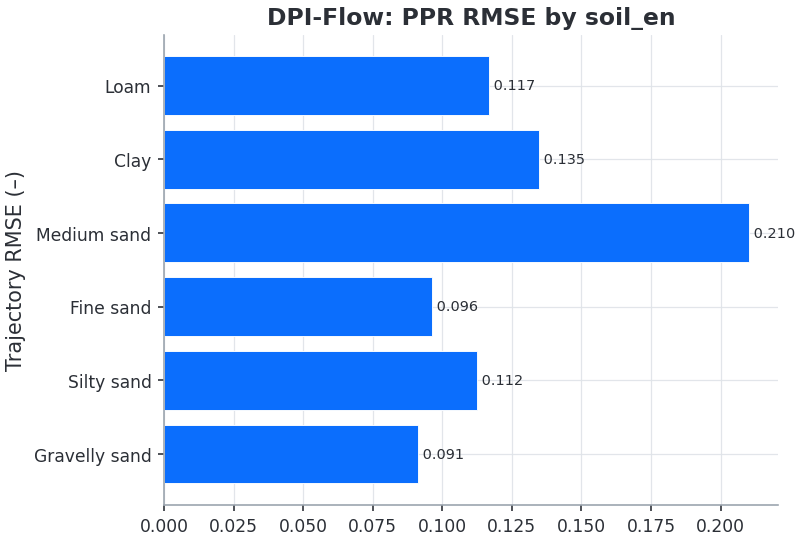


=== OOD по: диапазон CSR ===


,CSR_bin,N samples,Mean trajectory RMSE,Mean log-error N_liq,Physics violations,AUROC
0,CSR≤0.12,87,0.1121,0.0201,0.0,0.9512
1,0.12–0.18,41,0.0726,0.1964,0.0,NaN
2,0.18–0.25,20,0.0702,0.2413,0.0,NaN
3,CSR>0.25,20,0.4043,0.3014,0.0,NaN


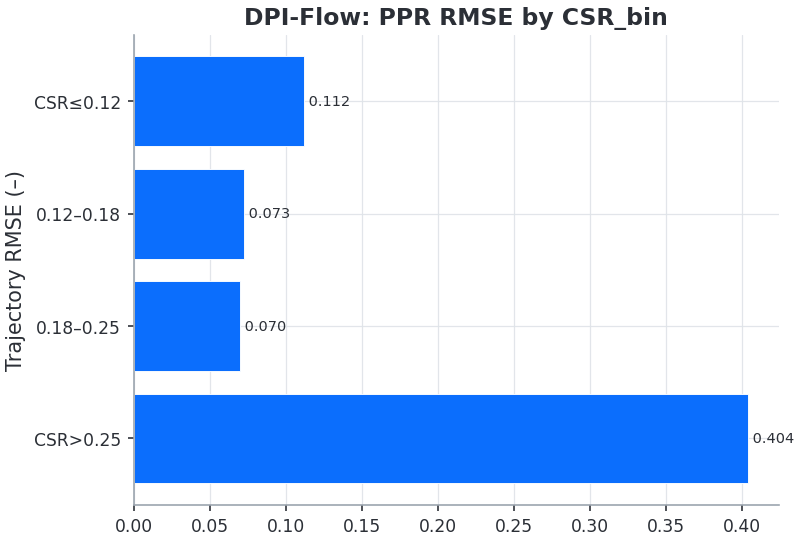

In [5]:
# === OOD-разбиение: качество по площадкам, типам грунтов и диапазонам CSR ===
# Для основной модели (DPI-Flow) считаем метрики по группам — генерализация по доменам.
from liquefaction_ai.evaluation import grouped_metrics
dpi_full, _, _ = load_trained("dpi_flow")
_out = collect_outputs(dpi_full, test, config, device)
_, sdf = compute_metrics("DPI-Flow", _out, test, config)
sdf["soil_en"] = sdf["soil_type"].map(SOIL_DISPLAY_NAMES_EN)
import numpy as np
sdf["CSR_bin"] = pd.cut(sdf["CSR_base"], [0, 0.12, 0.18, 0.25, 1.0],
                         labels=["CSR≤0.12", "0.12–0.18", "0.18–0.25", "CSR>0.25"])
_show = ["samples", "mean_traj_rmse", "mean_nliq_log_err", "physics_violation_rate", "AUROC"]
for dim, label in [("object", "площадка (site)"), ("soil_en", "тип грунта"), ("CSR_bin", "диапазон CSR")]:
    g = grouped_metrics(sdf, dim)
    print(f"\n=== OOD по: {label} ===")
    display(english_metric_table(g[[dim] + _show]).round(4))
    bar(g[dim].astype(str), g["mean_traj_rmse"], title=f"DPI-Flow: PPR RMSE by {dim}",
        ylabel="Trajectory RMSE (–)", color="#0b6efd", horizontal=True,
        save=SAVE_FIGS, fig_id=f"3_2_ood_{dim}").show()
    if dim in ("soil_en", "CSR_bin"):
        _fn = "ood_by_soil" if dim == "soil_en" else "ood_by_csr"
        g[[dim] + _show].round(4).to_csv(REPO_ROOT / "results" / "tables" / f"{_fn}.csv", index=False)